In [2]:
from dotenv import load_dotenv
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode
import os
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)



In [3]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
def chat_node(state: ChatState):
    reply = llm.invoke(state["messages"])
    return {"messages": [reply]}

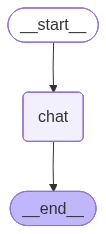

In [ ]:
builder = StateGraph(ChatState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile()
graph

In [20]:
graph.invoke({"messages": [HumanMessage(content="Hi, I am Rahul.")]})


{'messages': [HumanMessage(content='Hi, I am Rahul.', additional_kwargs={}, response_metadata={}, id='764c1e6e-1d6b-4f70-a83a-5b656fdc0834'),
  AIMessage(content='Hi Rahul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f26e464023', 'id': 'chatcmpl-E0MoZBKH3XP4V9c2GBAFdTSdTNJ90', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f502a-bd2c-7f51-9177-937396577570-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [21]:
graph.invoke({"messages": [HumanMessage(content="what is my name.")]})


{'messages': [HumanMessage(content='what is my name.', additional_kwargs={}, response_metadata={}, id='d2282fbe-6a8e-4054-805b-a776b483d6a6'),
  AIMessage(content="I'm sorry, but I don't have access to personal information about users unless it has been shared with me in the course of our conversation. If you'd like to tell me your name, feel free!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 12, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_db286bd4bf', 'id': 'chatcmpl-E0MpJL57TLS5q4umUAhPlo3PXc059', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f502b-7126-74e1-8876-3ad2f3424a02-0', tool_calls=[], invalid_t

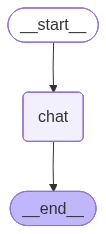

In [6]:
builder = StateGraph(ChatState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

memory = MemorySaver()
agent = builder.compile(checkpointer=memory)
agent

In [9]:
config_1 = {"configurable": {"thread_id": "chat-1"}}

In [10]:
agent.invoke({"messages": [HumanMessage(content="Hi, I am Rahul.")]}, config_1)


{'messages': [HumanMessage(content='who I am ', additional_kwargs={}, response_metadata={}, id='d9c858a1-523f-474e-a2c8-384e0e5927d0'),
  AIMessage(content="I don’t have access to personal data about individuals unless it has been shared with me in the course of our conversation. If you tell me more about yourself or what you're looking for, I might be able to help!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 11, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a17b1ca31d', 'id': 'chatcmpl-E0MsIQw1OkTVaRX1B3Q8NP0mgLzEO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f502e-4803-7641-b08f-5035cfedcda9-0', tool_c

In [11]:
agent.invoke({"messages": [HumanMessage(content="who I am ")]}, config_1)


{'messages': [HumanMessage(content='who I am ', additional_kwargs={}, response_metadata={}, id='d9c858a1-523f-474e-a2c8-384e0e5927d0'),
  AIMessage(content="I don’t have access to personal data about individuals unless it has been shared with me in the course of our conversation. If you tell me more about yourself or what you're looking for, I might be able to help!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 11, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a17b1ca31d', 'id': 'chatcmpl-E0MsIQw1OkTVaRX1B3Q8NP0mgLzEO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f502e-4803-7641-b08f-5035cfedcda9-0', tool_c

In [12]:
agent.invoke({"messages": [HumanMessage(content="suggest some good name for me ")]}, config_1)


{'messages': [HumanMessage(content='who I am ', additional_kwargs={}, response_metadata={}, id='d9c858a1-523f-474e-a2c8-384e0e5927d0'),
  AIMessage(content="I don’t have access to personal data about individuals unless it has been shared with me in the course of our conversation. If you tell me more about yourself or what you're looking for, I might be able to help!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 11, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a17b1ca31d', 'id': 'chatcmpl-E0MsIQw1OkTVaRX1B3Q8NP0mgLzEO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f502e-4803-7641-b08f-5035cfedcda9-0', tool_c